# Sivers: the $R_1 < 0.3$ cut, with and without

A copy of `plot-sivers_phicompare.ipynb`, narrowed to SBS, 2π and the
4 × 24° run on 2π's bins, with one question added: **what does the collinearity cut $R_1 < 0.3$ cost?**
Each entry is drawn in one panel with its cut twin, which is the same run fitted with
`-t 0.3` and so keeps only the simulated rows with $R_1 < 0.3$. $R_1$ is the
current-fragmentation criterion of arXiv:1611.10329 (`tmd.CalculateRfactor`;
see `physics.md`).

| key | run directory | acceptance | binning | rows, no cut | rows, $R_1<0.3$ | counts |
|---|---|---|---|---|---|---|
| `world` | `../data_world` | world data, **the reference, never cut** | — | 234 | 234 | — |
| `sbs` | `../data_sbs` | SBS projection, **stat-only panel** | — | 455 | 320 | 1x |
| `phifull` | `data_phifull` | full 2π | own | 1660 | 928 | 1x |
| `phi4seg_fullbin_x4` | `data_phi4seg24deg_phifullbin` | 4 × 24°, both arms | reused from `phifull` | 1660 | 859 | 4x |

The cut twins carry the key suffix `_r1`. Row counts are the ones the fits
printed (`runlog.md`, 2026-09-02 and 2026-09-08).

**The world data is never cut.** The filter sits inside `fitsim()`, and
`fitworld()` does not call it. So `world` is the same fit in every panel, and a
ratio to world measures the SoLID side alone.

**Luminosity is the same on both sides of each pair.** The 4x φ-cut runs are
compared with their 4x cut twins (`_r1lt0.3_x4counts`), and 2π and SBS with
their 1x twins. So the cut/no-cut ratio isolates the cut. It is **not** the same
across configurations, so compare the cut *penalty* between them, never the
raw bands.

**Why 2π bins for the φ cut.** `phi4seg_fullbin_x4` shares `phifull`'s 1660
bins, so the two lose the same bins to the cut (928 and 859 of 1660 survive)
and their penalties compare like for like.

**Standing caveat (`runlog.md`, 2026-09-02).** Every uncut fit already has
χ²/ndof < 1, and the cut pushes it further down rather than towards 1. If the
rows it discards were the ones the TMD model fits badly, χ²/ndof should have
risen. Why it falls is unresolved, so read the cut's effect on the *errors*
here, not as evidence that the model fits the TMD region better.

Figures go to `gallery_r1lt0.3/` under the same names the base notebooks use in
`gallery/`, so a figure and its uncut counterpart differ only by directory.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath('..'))   # tmd.py lives at the repo root
import tmd

GALLERY = 'gallery_r1lt0.3'   # same figure names as gallery/
os.makedirs(GALLERY, exist_ok=True)

Q2  = 2.4    # the single Q2 the ratio tables use
# The band figures draw every entry: the first carries the error band, any others
# would be central curves showing the Q2 evolution.
# One Q2. The machinery below still loops, so adding values back is a
# one-line change; with a single entry the band is drawn and nothing else.
Q2LIST = [2.4]
tol = 1.5    # Sivers value (the transversity notebook uses 7.04); it cancels in
             # every error RATIO below, so the comparisons do not depend on it

LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/CJ15lo/CJ15lo_0000.dat
CJ15lo PDF set, member #0, version 2; LHAPDF ID = 12300
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0211.dat
DSSFFlo PDF set, member #211, version 1; LHAPDF ID = 90211
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/DSSFFlo/DSSFFlo_0321.dat
DSSFFlo PDF set, member #321, version 1; LHAPDF ID = 90321
LHAPDF 6.5.6 loading /group/solid/apps/evgen/LHAPDF/LHAPDF-6.5.6/share/LHAPDF/NNPDFpol11_100/NNPDFpol11_100_0000.dat
NNPDFpol11_100 PDF set, member #0, version 1; LHAPDF ID = 251000


## Load fit results

Each file is the raw per-replica parameter table (50 rows x `Nu,au,bu,cu,Nd,ad,bd,cd,Nub,Ndb,kt2,chi2`).

In [2]:
OBS = 'sivers'
STAT, SYST = f'out-enhanced3he_sivers.dat', f'out-enhanced3hesyst_sivers.dat'

# The fit scripts' filename suffixes. -t 0.3 inserts _r1lt0.3 right after the
# observable and -c 4 appends _x4counts, so a cut 4x fit is
# out-enhanced3he_sivers_r1lt0.3_x4counts.dat. R1 goes in after the observable
# rather than before .dat, so it composes with X4 in either order.
X4 = lambda f: f.replace('.dat', '_x4counts.dat')
R1 = lambda f: f.replace(f'_sivers', f'_sivers_r1lt0.3')

REF    = 'world'
CUTSUF = '_r1'          # key suffix of a cut twin

# Three of the four entries in plot-sivers_phicompare.ipynb, at the same luminosities:
# 2pi and SBS at 1x, the phi-cut run at 4x (why: see that notebook). The own-bins
# phi-cut run is left out: it re-bins under its own acceptance, so its cut removes
# different bins from phifull's.
BASE_RUNS = {
    'world':              {'dir': '../data_world',
                           'files': {'': f'out-world_sivers.dat', 'syst': f'out-world_sivers.dat'},
                           'label': r'$\rm world~data$',
                           'color': 'gray'},
    'sbs':                {'dir': '../data_sbs',
                           'files': {'': f'out-sbs_sivers.dat'},
                           'label': r'$\rm SBS$',
                           'color': 'saddlebrown'},
    'phifull':            {'dir': 'data_phifull',
                           'files': {'': STAT, 'syst': SYST},
                           'label': r'$\rm SoLID~full~2\pi$',
                           'color': 'black'},
    'phi4seg_fullbin_x4': {'dir': 'data_phi4seg24deg_phifullbin',
                           'files': {'': X4(STAT), 'syst': X4(SYST)},
                           'label': r'$\rm 4\times24^\circ~(2\pi~bins,~4\times~counts)$',
                           'color': 'green'},
}

# Every entry except world gets a cut twin, inserted right after it: same run
# directory, same luminosity, the -t 0.3 fit. 'cut_of' names the uncut partner.
# The world fit has no twin, because the cut never touches the world data.
RUNS = {}
for run, cfg in BASE_RUNS.items():
    RUNS[run] = cfg
    if run == REF:
        continue
    RUNS[run + CUTSUF] = dict(cfg,
                              files={k: R1(v) for k, v in cfg['files'].items()},
                              label=cfg['label'] + r'$,~R_1<0.3$',
                              cut_of=run)

# the uncut SoLID/SBS entries; each is drawn with its cut twin in its own colour
CONFIGS = [r for r, c in RUNS.items() if r != REF and 'cut_of' not in c]

# SBS has no systematics model of its own, so it has no 'syst' fit. runs_for()
# therefore leaves it (and its twin) out of every stat+syst panel.
def runs_for(suffix):
    return [(run, cfg) for run, cfg in RUNS.items() if suffix in cfg['files']]

VARIANTS = ['', 'syst']

par = {}
for run, cfg in RUNS.items():
    for suf in VARIANTS:
        if suf not in cfg['files']:
            print(f'{run+suf:26s} {"-- no fit; absent from this panel":62s}')
            continue
        path = os.path.join(cfg['dir'], cfg['files'][suf])
        par[run + suf] = pd.read_csv(path, sep=r'\s+', index_col=False)
        print(f'{run+suf:26s} {path:62s} {len(par[run+suf])} replicas')

world                      ../data_world/out-world_sivers.dat                             500 replicas
worldsyst                  ../data_world/out-world_sivers.dat                             500 replicas
sbs                        ../data_sbs/out-sbs_sivers.dat                                 500 replicas
sbssyst                    -- no fit; absent from this panel                             
sbs_r1                     ../data_sbs/out-sbs_sivers_r1lt0.3.dat                         500 replicas
sbs_r1syst                 -- no fit; absent from this panel                             
phifull                    data_phifull/out-enhanced3he_sivers.dat                        500 replicas
phifullsyst                data_phifull/out-enhanced3hesyst_sivers.dat                    500 replicas
phifull_r1                 data_phifull/out-enhanced3he_sivers_r1lt0.3.dat                500 replicas
phifull_r1syst             data_phifull/out-enhanced3hesyst_sivers_r1lt0.3.dat            500 repli

phi4seg_fullbin_x4         data_phi4seg24deg_phifullbin/out-enhanced3he_sivers_x4counts.dat 500 replicas
phi4seg_fullbin_x4syst     data_phi4seg24deg_phifullbin/out-enhanced3hesyst_sivers_x4counts.dat 500 replicas
phi4seg_fullbin_x4_r1      data_phi4seg24deg_phifullbin/out-enhanced3he_sivers_r1lt0.3_x4counts.dat 500 replicas
phi4seg_fullbin_x4_r1syst  data_phi4seg24deg_phifullbin/out-enhanced3hesyst_sivers_r1lt0.3_x4counts.dat 500 replicas


### Fitted parameters, run by run

In [3]:
rows = []
for key, p in par.items():
    r = {'run': key}
    for c in p.columns:
        r[c] = f'{p[c].mean():.4f} +- {p[c].std():.4f}'
    rows.append(r)
pd.set_option('display.width', 250)
partable = pd.DataFrame(rows).set_index('run')
partable[['Nu', 'au', 'bu', 'Nd', 'ad', 'bd', 'kt2', 'chi2']]

,Nu,au,bu,Nd,ad,bd,kt2,chi2
run,,,,,,,,
world,-0.0387 +- 0.0019,0.6663 +- 0.1130,4.1564 +- 1.0440,0.0576 +- 0.0154,0.4381 +- 0.2504,3.8314 +- 3.1709,0.1592 +- 0.0300,226.1234 +- 20.8210
worldsyst,-0.0387 +- 0.0019,0.6663 +- 0.1130,4.1564 +- 1.0440,0.0576 +- 0.0154,0.4381 +- 0.2504,3.8314 +- 3.1709,0.1592 +- 0.0300,226.1234 +- 20.8210
sbs,-0.0357 +- 0.0081,0.6078 +- 0.0642,4.2252 +- 1.0423,0.0470 +- 0.0088,0.3318 +- 0.0861,3.4107 +- 0.7871,0.1591 +- 0.0150,449.2308 +- 30.6505
sbs_r1,-0.0353 +- 0.0077,0.6096 +- 0.0665,4.2939 +- 0.9853,0.0476 +- 0.0088,0.3386 +- 0.0835,3.3611 +- 0.9450,0.1595 +- 0.0134,314.8765 +- 25.2520
phifull,-0.0374 +- 0.0064,0.6315 +- 0.0472,4.1441 +- 0.8068,0.0499 +- 0.0051,0.3714 +- 0.0485,3.3170 +- 0.5645,0.1600 +- 0.0016,1650.3382 +- 56.9493
phifullsyst,-0.0373 +- 0.0066,0.6277 +- 0.0475,4.1453 +- 0.8341,0.0497 +- 0.0057,0.3633 +- 0.0589,3.3128 +- 0.6192,0.1600 +- 0.0038,1650.6999 +- 56.9243
phifull_r1,-0.0365 +- 0.0067,0.6239 +- 0.0583,4.2314 +- 0.8204,0.0499 +- 0.0056,0.3674 +- 0.0617,3.3048 +- 0.6016,0.1599 +- 0.0056,919.9732 +- 44.7559
phifull_r1syst,-0.0364 +- 0.0071,0.6198 +- 0.0610,4.2234 +- 0.8544,0.0499 +- 0.0064,0.3628 +- 0.0654,3.2735 +- 0.6726,0.1598 +- 0.0094,920.4182 +- 44.7780
phi4seg_fullbin_x4,-0.0361 +- 0.0085,0.6087 +- 0.0756,4.2501 +- 1.0429,0.0489 +- 0.0064,0.3563 +- 0.0677,3.4047 +- 0.7111,0.1602 +- 0.0034,1651.1967 +- 56.8811


## Calculate $xf_{1T}^{\perp(1)}(x)$

Follows `f1tcalc()` in `plot-sivers.ipynb`: for each $x$, evaluate
`tmd.f1Tperp1` once per replica using that replica's own parameters, take the
valence combination $q - \bar q$, then central value = mean, error = `tol` × std.

(`Nub`/`Ndb` are fixed to 0 in `fitsim`, so the $\bar q$ terms vanish — the
subtraction is kept for fidelity with the reference notebook.)

In [4]:
def f1tcalcorr(pset, Q2, tol):
    rows = []
    X = np.linspace(1e-3, 1, 200)
    pset = pset.reset_index(drop=True)
    for x in X:
        # errors only -- central values are untouched. Identically 1 for x <= 0.4,
        # exp(-6.8*(x-0.4)^2) above: x0.76 at x=0.6, x0.34 at x=0.8, x0.09 at x=1.
        corr = np.exp(-1.7 * (np.abs(x - 0.4) + x - 0.4)**2)
        xu, xd = [], []
        for i in range(len(pset)):
            f1t = tmd.f1Tperp1(x, Q2, 'proton', pset.loc[i])
            xu.append(x * (f1t[2] - f1t[-2]))
            xd.append(x * (f1t[1] - f1t[-1]))
        rows.append({'x': x,
                     'xu': np.mean(xu), 'Exu': tol * np.std(xu) * corr,
                     'xd': np.mean(xd), 'Exd': tol * np.std(xd) * corr})
    return pd.DataFrame(rows)

In [5]:
%%time
f1t = {}
for q2 in Q2LIST:
    f1t[q2] = {}
    for key in par:
        f1t[q2][key] = f1tcalcorr(par[key], q2, tol)
    print('done Q2 =', q2)

done Q2 = 2.4
CPU times: user 2min 20s, sys: 75.6 ms, total: 2min 20s
Wall time: 2min 21s


## $xf_{1T}^{\perp(1)}(x)$ bands: every configuration, no cut vs $R_1 < 0.3$, in one plot

Top: world (gray) and each configuration in its own colour. **Filled band, solid
line = no cut; dashed lines = the edges of the $R_1<0.3$ band.** $u$ and $d$ are the two
lobes and are labelled on the curves. Bottom: **Error($R_1<0.3$) / Error(no cut)**
per configuration, $u$ solid and $d$ dashed. Above 1 means the cut costs
precision. `tol` cancels in it, and so does the luminosity, since both members of
a pair were fitted at the same counts.

In [6]:
def band_plot(suffix, fname, title):
    runs = [r for r in CONFIGS if suffix in RUNS[r]['files']]
    fig = plt.figure(figsize=(6.5, 10))
    q2 = Q2LIST[0]

    ax = fig.add_subplot(2, 1, 1)
    d = f1t[q2][REF + suffix]
    for q in ('xu', 'xd'):
        ax.fill_between(d['x'], d[q] - d['E' + q], d[q] + d['E' + q],
                        color=RUNS[REF]['color'], alpha=0.30, linewidth=0)
        ax.plot(d['x'], d[q], color=RUNS[REF]['color'], linewidth=1.2,
                label=RUNS[REF]['label'] if q == 'xu' else None)
    for run in runs:
        color = RUNS[run]['color']
        for key, cut in ((run + CUTSUF, True), (run, False)):   # wider cut band first
            d = f1t[q2][key + suffix]
            for q in ('xu', 'xd'):
                lo, hi = d[q] - d['E' + q], d[q] + d['E' + q]
                if cut:     # the cut band as its two dashed edges, so the fills stay readable
                    for edge in (lo, hi):
                        ax.plot(d['x'], edge, color=color, linestyle='--', linewidth=1.3,
                                label=RUNS[key]['label'] if (q == 'xu' and edge is lo) else None)
                else:
                    ax.fill_between(d['x'], lo, hi, color=color, alpha=0.30, linewidth=0)
                    ax.plot(d['x'], d[q], color=color, linewidth=1.2,
                            label=RUNS[key]['label'] if q == 'xu' else None)
    ax.axhline(y=0, linestyle='-', color='black', alpha=0.9, linewidth=1)
    for xv in (0.05, 0.60):
        ax.axvline(x=xv, linestyle=':', color='black', alpha=0.7, linewidth=1)
    ax.set_ylabel(r'$xf_{1T}^{\perp(1)}(x)$', size=25)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(-0.042, 0.05)
    ax.set_xticklabels([])
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.text(0.5, 0.96, title, horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, fontsize=15)
    ax.text(0.03, 0.89, r'$Q^2 = ' + f'{q2:g}' + r'~{\rm GeV}^2$',
            transform=ax.transAxes, fontsize=13)
    # u and d labelled ON the curves, placed by the sign of each lobe
    dref = f1t[q2][REF + suffix]
    j = int(np.argmin(np.abs(dref['x'].values - 0.15)))   # clear of the legend
    lo, hi = ax.get_ylim()
    pad = 0.07 * (hi - lo)
    for q, lab in (('xu', 'u'), ('xd', 'd')):
        v = dref[q].values[j]
        ax.text(0.15, v + (pad if v >= 0 else -pad), rf'${lab}$', fontsize=19,
                ha='center', va='bottom' if v >= 0 else 'top', color='black')
    ax.legend(loc='lower right', frameon=False, fontsize=9)

    ax = fig.add_subplot(2, 1, 2)
    rmax = 1.0
    for run in runs:
        d0, d1 = f1t[q2][run + suffix], f1t[q2][run + CUTSUF + suffix]
        inx = (d0['x'] >= 0.05) & (d0['x'] <= 0.6)
        for q, ls, lab in (('Exu', '-', 'u'), ('Exd', '--', 'd')):
            r = d1[q] / d0[q]
            rmax = max(rmax, r[inx].max())
            ax.plot(d0['x'], r, color=RUNS[run]['color'], linestyle=ls, linewidth=2.5,
                    alpha=0.8, label=RUNS[run]['label'] + rf'$~{lab}$')
    ax.axhline(y=1, linestyle='-', color='black', alpha=0.6, linewidth=1)
    for xv in (0.05, 0.60):
        ax.axvline(x=xv, linestyle=':', color='black', alpha=0.7, linewidth=1)
    ax.set_xlabel(r'$x$', size=25)
    ax.set_ylabel(r'$\rm Error^{R_1<0.3}/Error^{no~cut}$', size=20)
    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 1.25 * rmax)     # headroom for the legend
    ax.tick_params(axis='both', which='both', direction='in', labelsize=20)
    ax.legend(loc='upper right', frameon=False, fontsize=9, ncol=2)

    fig.tight_layout()
    fig.savefig(f'{GALLERY}/{fname}')
    return fig

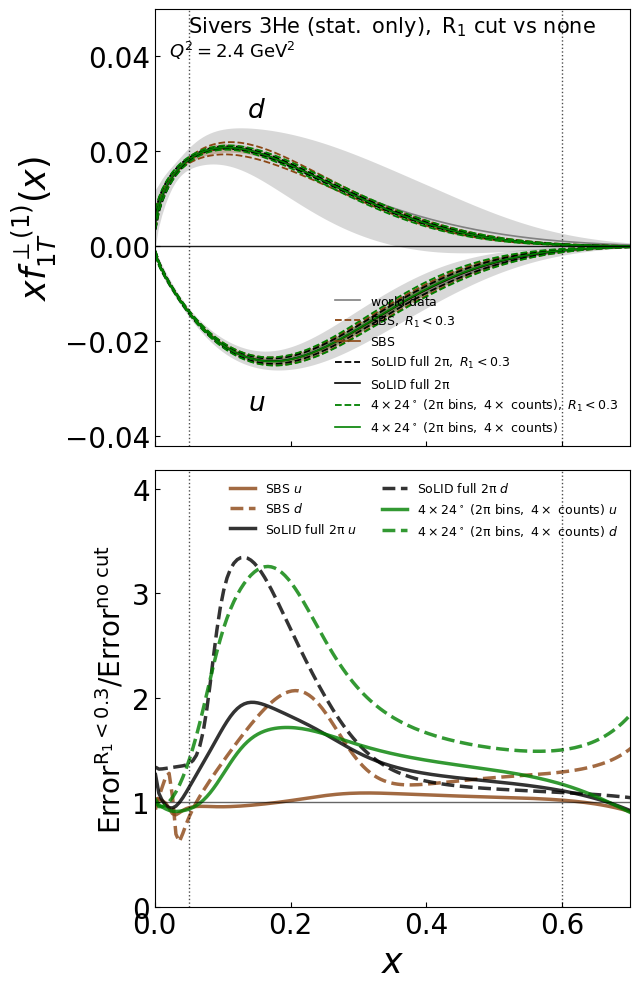

In [7]:
band_plot('', 'sivers-phicompare.pdf',
          r'$\rm Sivers~3He~(stat.~only),~R_1~cut~vs~none$');

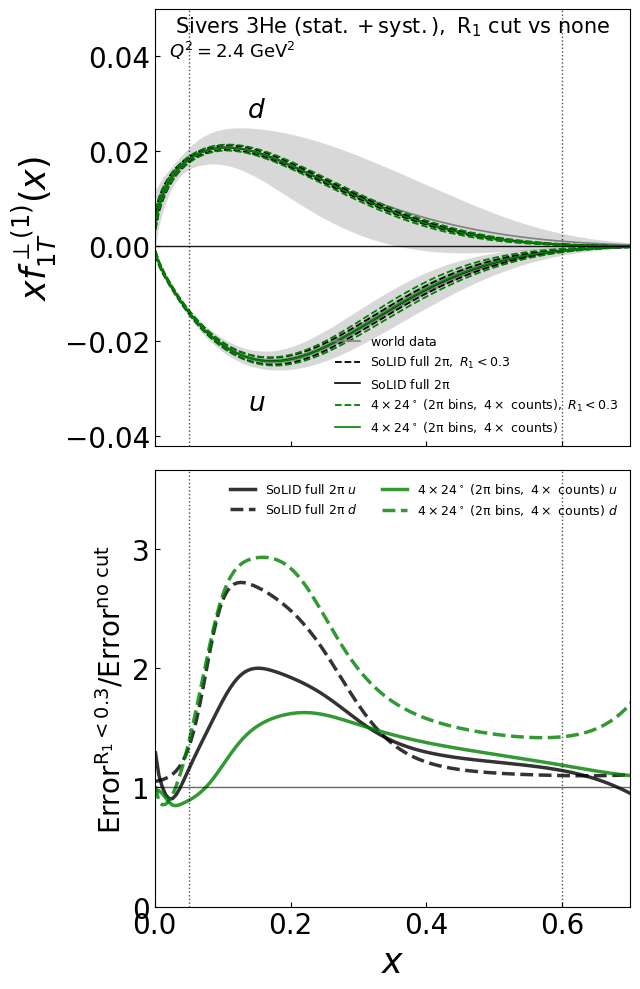

In [8]:
band_plot('syst', 'sivers-phicompare-syst.pdf',
          r'$\rm Sivers~3He~(stat.+syst.),~R_1~cut~vs~none$');

## Uncertainty ratios at representative $x$

First table: Error(world)/Error for every entry, cut and uncut. This is the same
table as the base notebook, with the cut twins added. Second table: the cut
penalty, Error($R_1<0.3$)/Error(no cut), which is the bottom row of the band
figures in numbers.

In [9]:
XPTS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

rows = []
for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    ref = f1t[Q2LIST[0]][REF + suffix]
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        d = f1t[Q2LIST[0]][run + suffix]
        for q, lab in [('Exu', 'u'), ('Exd', 'd')]:
            r = {'variant': sname, 'run': run, 'quark': lab}
            for x in XPTS:
                j = int(np.argmin(np.abs(d['x'].values - x)))
                r[f'x={x}'] = round(ref[q].values[j] / d[q].values[j], 2)
            rows.append(r)
print('Error^world / Error  (larger = SoLID better; 20 means 20x more precise)')
pd.DataFrame(rows).set_index(['variant', 'run', 'quark'])

Error^world / Error  (larger = SoLID better; 20 means 20x more precise)


x=0.05  x=0.1  x=0.2  x=0.3  x=0.4  x=0.5  x=0.6
variant   run                   quark                                                  
stat      sbs                   u        3.98   3.15   2.60   3.53   3.24   2.92   2.86
                                d        3.42   4.17  12.43  18.58  15.41  14.60  17.35
          sbs_r1                u        4.20   3.29   2.56   3.25   3.02   2.78   2.80
                                d        3.94   2.99   6.02  13.51  13.15  11.83  13.48
          phifull               u        3.37   6.35   7.19   7.93   6.28   5.14   4.63
                                d        8.89  46.54  56.69  47.77  34.14  28.86  31.28
          phifull_r1            u        2.93   3.69   3.96   5.41   4.92   4.29   4.16
                                d        6.48  15.38  21.53  30.99  28.35  25.59  28.62
          phi4seg_fullbin_x4    u        2.55   3.53   4.15   4.05   3.39   3.02   2.78
                                d        5.60  23.08  31.60  23.79  18.17  17.01  19.96
          phi4seg_fullbin_x4_r1 u        2.72   2.77   2.42   2.62   2.42   2.31   2.37
                                d        3.95   8.65  10.22  11.48  10.89  11.20  13.31
stat+syst phifull               u        2.83   4.76   5.89   7.27   5.96   4.95   4.51
                                d        5.59  20.98  35.17  39.21  30.04  25.87  28.35
          phifull_r1            u        2.43   2.74   3.07   4.69   4.59   4.08   3.94
                                d        4.13   8.11  14.22  23.44  24.70  23.08  25.80
          phi4seg_fullbin_x4    u        2.41   3.25   3.90   3.94   3.30   2.94   2.78
                                d        4.74  15.80  25.40  21.86  16.73  15.65  18.40
          phi4seg_fullbin_x4_r1 u        2.70   2.72   2.41   2.59   2.39   2.29   2.35
                                d        3.37   6.00   8.98  11.07  10.58  10.82  12.93

In [10]:
rows = []
for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    for run in CONFIGS:
        if suffix not in RUNS[run]['files']:
            continue
        d0 = f1t[Q2LIST[0]][run + suffix]
        d1 = f1t[Q2LIST[0]][run + CUTSUF + suffix]
        for q, lab in [('Exu', 'u'), ('Exd', 'd')]:
            r = {'variant': sname, 'run': run, 'quark': lab}
            for x in XPTS:
                j = int(np.argmin(np.abs(d0['x'].values - x)))
                r[f'x={x}'] = round(d1[q].values[j] / d0[q].values[j], 2)
            rows.append(r)
print('Error(R1<0.3) / Error(no cut)  (above 1 = the cut costs precision)')
pd.DataFrame(rows).set_index(['variant', 'run', 'quark'])

Error(R1<0.3) / Error(no cut)  (above 1 = the cut costs precision)


x=0.05  x=0.1  x=0.2  x=0.3  x=0.4  x=0.5  x=0.6
variant   run                quark                                                  
stat      sbs                u        0.95   0.96   1.02   1.09   1.07   1.05   1.02
                             d        0.87   1.40   2.06   1.38   1.17   1.23   1.29
          phifull            u        1.15   1.72   1.82   1.46   1.28   1.20   1.11
                             d        1.37   3.03   2.63   1.54   1.20   1.13   1.09
          phi4seg_fullbin_x4 u        0.94   1.28   1.71   1.55   1.40   1.31   1.17
                             d        1.42   2.67   3.09   2.07   1.67   1.52   1.50
stat+syst phifull            u        1.17   1.74   1.92   1.55   1.30   1.21   1.14
                             d        1.35   2.59   2.47   1.67   1.22   1.12   1.10
          phi4seg_fullbin_x4 u        0.89   1.20   1.62   1.52   1.38   1.28   1.19
                             d        1.40   2.63   2.83   1.97   1.58   1.45   1.42

## Parameter-level summary

The Sivers fit has no tensor-charge analogue of $g_T$, so the compact summary is
the replica spread of the fitted parameters themselves. `kt2` is the one to
watch: it sets the transverse-momentum width, which is what an azimuthal
acceptance cut degrades most directly.

**Do not read the "vs world" parameter column as a precision comparison.**
`fitworld()` and `fitsim()` fix *different* parameters: the world fit floats 7
(`fix=[F,F,F,T,F,F,F,T,T,T,F]` — `cu`, `cd`, `Nub`, `Ndb` held), while the SoLID
fits float 9 (only `Nub`, `Ndb` held). Letting `cu`/`cd` float gives the SoLID
replicas extra freedom that inflates individual parameter spreads, which is why
`Nu` comes out with a *larger* std than world's despite SoLID being far more
precise on the actual observable. The band ratios above (which marginalise over
the whole parameter set) are the meaningful comparison against world; the
run-to-run column below, which compares like-configured `fitsim` outputs to each
other, is the meaningful one for the φ-cut effect.

In [11]:
COLS = ['Nu', 'au', 'bu', 'Nd', 'ad', 'bd', 'kt2']

for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    print(f'--- {sname}: std(world)/std, larger = better '
          f'(NOT a precision comparison -- different params fixed, see above) ---')
    ref = par[REF + suffix]
    for run, cfg in runs_for(suffix):
        cells = [f'{c}={ref[c].std()/par[run+suffix][c].std():.2f}' for c in COLS]
        print(f'  {run:22s} ' + '  '.join(cells))
    print()

for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    print(f'--- {sname}: replica-std ratio to SoLID full-2pi '
          f'(like-for-like -- this is the phi-cut effect) ---')
    for run, cfg in runs_for(suffix):
        if run == REF:
            continue
        # a cut twin is measured against the CUT 2pi run, so this block
        # stays the phi-cut effect alone; the R1 penalty is the next block
        ref = par['phifull' + (CUTSUF if 'cut_of' in cfg else '') + suffix]
        cells = [f'{c}={par[run+suffix][c].std()/ref[c].std():.3f}' for c in COLS]
        print(f'  {run:22s} ' + '  '.join(cells))
    print()

for suffix, sname in [('', 'stat'), ('syst', 'stat+syst')]:
    print(f'--- {sname}: R1 cut penalty, std(R1<0.3) / std(no cut) ---')
    for run in CONFIGS:
        if suffix not in RUNS[run]['files']:
            continue
        a, b = par[run + CUTSUF + suffix], par[run + suffix]
        cells = [f'{c}={a[c].std()/b[c].std():.3f}' for c in COLS]
        print(f'  {run:22s} ' + '  '.join(cells))
    print()

print('--- systematics penalty: std(stat+syst) / std(stat) ---')
for run, cfg in runs_for('syst'):
    if run == REF:
        continue          # world has no syst variant; SBS is already excluded
    cells = [f'{c}={par[run+"syst"][c].std()/par[run][c].std():.2f}' for c in COLS]
    print(f'  {run:18s} ' + '  '.join(cells))
print()
print('Ratios marginally below 1.0 are 500-replica sampling noise (3.2%), not a')
print('real reduction -- adding systematics cannot shrink an error. Use them as')
print('the scale for how much of the near-1.0 numbers above is meaningful.')

--- stat: std(world)/std, larger = better (NOT a precision comparison -- different params fixed, see above) ---
  world                  Nu=1.00  au=1.00  bu=1.00  Nd=1.00  ad=1.00  bd=1.00  kt2=1.00
  sbs                    Nu=0.23  au=1.76  bu=1.00  Nd=1.76  ad=2.91  bd=4.03  kt2=2.00
  sbs_r1                 Nu=0.24  au=1.70  bu=1.06  Nd=1.75  ad=3.00  bd=3.36  kt2=2.25
  phifull                Nu=0.29  au=2.39  bu=1.29  Nd=3.00  ad=5.17  bd=5.62  kt2=18.58
  phifull_r1             Nu=0.28  au=1.94  bu=1.27  Nd=2.73  ad=4.06  bd=5.27  kt2=5.32
  phi4seg_fullbin_x4     Nu=0.22  au=1.49  bu=1.00  Nd=2.43  ad=3.70  bd=4.46  kt2=8.79
  phi4seg_fullbin_x4_r1  Nu=0.22  au=1.40  bu=0.96  Nd=1.85  ad=3.26  bd=3.41  kt2=2.90

--- stat+syst: std(world)/std, larger = better (NOT a precision comparison -- different params fixed, see above) ---
  world                  Nu=1.00  au=1.00  bu=1.00  Nd=1.00  ad=1.00  bd=1.00  kt2=1.00
  phifull                Nu=0.28  au=2.38  bu=1.25  Nd=2.71  ad=4